In [81]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from pandas import DataFrame
from analytics.metrics.metric import MetricCalculator
from analytics.metrics.time import TimeMetrics
from spec.enums import MainTableColumns as Cols
from spec.spec_definition import PS2Versions
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [220]:
from analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor
from analytics.preprocessors.codebench import YAMLLinkURLPreprocessor
from analytics.ps2_dataset import SortPreprocessor
from spec.enums import EventType

config_path = None
problem_id_col = None
timestamp_col = None
idle_gap = None
break_gap = None
proprocessing_steps = []
link_preprocessing_steps = []
submit_event = EventType.Submit
grades_link_table = "Subject"
grades_col = None

edwards2021_config = {
    "config_path": "sample_data_configs/edwards2021.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [
        TimeStampToDateTimePreprocessor(),
        SortPreprocessor()
    ],
}

cwo_s19_config = {
    "config_path": "sample_data_configs/cwo_s19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor()
    ],
    "submit_event": EventType.RunProgram,
}

cwo_f19_config = {
    "config_path": "sample_data_configs/cwo_f19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor()
    ],
    "submit_event": EventType.RunProgram,
}

codebench2024_config = {
    "config_path": "sample_data_configs/codebench2024.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],
    "grades_link_table": "CourseSubject",
    "grades_col": "final-grade",
}

config = codebench2024_config
# config = cwo_s19_config
# config = cwo_f19_config
locals().update(config)

In [173]:
from database.config import PS2DataConfig

spec = PS2Versions.v1_0.load()

data_config = PS2DataConfig.from_yaml(config_path, spec)


In [174]:
from analytics.ps2_dataset import PS2Dataset

dataset = PS2Dataset(spec, data_config)
for i, step in enumerate(proprocessing_steps):
    dataset.main_table_preprocessors.insert(i, step)
for i, step in enumerate(link_preprocessing_steps):
    dataset.link_table_preprocessors.insert(i, step)

In [175]:
main_table = dataset.get_main_table()
main_table.head()

,EventID,EventType,Order,SubjectID,CodeStateID,ProjectID,ToolInstances,ServerTimestamp,AssignmentID,ProblemID,...,ExecutionID,ExecutionResult,X-ExecutionTime,ProgramInput,ProgramOutput,ProgramErrorOutput,EditType,X-InsertText,SourceLocation,CodeStateSection
0,1224181,File.Focus,0,1837898832,NaN,NaN,Python 3.8.5,2024-05-12 15:57:04.334,4.070595e+09,9.529734e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main.py
1,1224182,X-File.Blur,1,1837898832,NaN,NaN,Python 3.8.5,2024-05-12 15:57:36.562,4.070595e+09,9.529734e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main.py
2,1217446,File.Focus,2,1837898832,NaN,NaN,Python 3.8.5,2024-05-12 15:59:19.589,4.070595e+09,1.471865e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main.py
3,1217448,File.Edit,3,1837898832,NaN,NaN,Python 3.8.5,2024-05-12 15:59:23.102,4.070595e+09,1.471865e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,Insert,i,Text:0,main.py
4,1217445,File.Edit,4,1837898832,NaN,NaN,Python 3.8.5,2024-05-12 15:59:23.209,4.070595e+09,1.471865e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,Insert,f,Text:1,main.py


In [178]:
bad_assignment_ids = [407610653, 1147927607, 1407437764]
main_table = main_table[~main_table[Cols.AssignmentID].isin(bad_assignment_ids)]

In [ ]:
# TODO: CONFIG
start_time = "2024-09-01 00:00:00"
main_table = main_table[main_table[timestamp_col] >= start_time]

AssignmentID
1.998810e+07    Axes(0.125,0.11;0.775x0.77)
5.855236e+07    Axes(0.125,0.11;0.775x0.77)
6.971731e+07    Axes(0.125,0.11;0.775x0.77)
1.192491e+08    Axes(0.125,0.11;0.775x0.77)
2.163590e+08    Axes(0.125,0.11;0.775x0.77)
                           ...             
4.070595e+09    Axes(0.125,0.11;0.775x0.77)
4.102703e+09    Axes(0.125,0.11;0.775x0.77)
4.195344e+09    Axes(0.125,0.11;0.775x0.77)
4.205900e+09    Axes(0.125,0.11;0.775x0.77)
4.270670e+09    Axes(0.125,0.11;0.775x0.77)
Name: ServerTimestamp, Length: 118, dtype: object

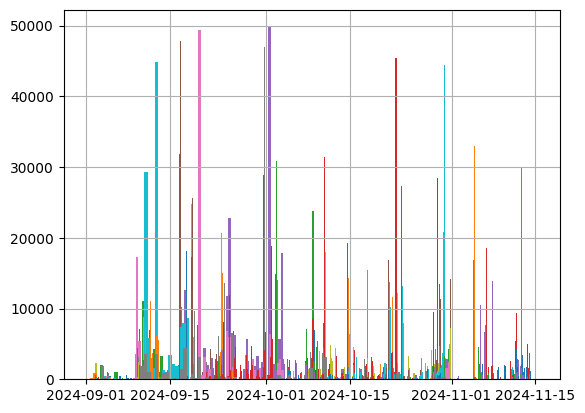

In [ ]:
main_table.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)

In [187]:
import numpy as np
for i in main_table[Cols.ServerTimestamp].quantile(np.arange(0, 1.01, 0.01)).to_list():
    print(i)

2024-09-01 00:20:42.870000128
2024-09-09 14:53:28.988669952
2024-09-09 22:32:31.066360064
2024-09-10 15:31:38.924460032
2024-09-10 19:23:05.686000128
2024-09-10 22:56:45.782449920
2024-09-11 02:57:43.517679872
2024-09-11 14:23:09.957900032
2024-09-11 17:13:19.854160128
2024-09-11 18:39:55.460950016
2024-09-12 00:09:09.880599808
2024-09-12 18:09:42.392270080
2024-09-12 19:32:09.884160
2024-09-13 02:32:07.591859968
2024-09-16 00:29:25.765460224
2024-09-16 17:00:22.937750016
2024-09-16 19:21:09.857559808
2024-09-17 01:05:59.377520128
2024-09-17 15:13:52.980000
2024-09-17 18:14:42.987909888
2024-09-17 19:12:50.927200
2024-09-17 23:02:56.898930176
2024-09-18 15:19:25.234400
2024-09-18 19:05:36.052649984
2024-09-19 00:37:40.014240
2024-09-19 18:29:01.357999872
2024-09-19 20:38:43.344679936
2024-09-20 20:41:51.538340096
2024-09-21 23:59:49.566320128
2024-09-23 13:10:44.086739968
2024-09-23 17:14:22.415399936
2024-09-23 19:08:01.364440064
2024-09-24 00:52:20.296600064
2024-09-24 18:20:16.93228

In [190]:
#get the data of the third quantile
max = main_table[Cols.ServerTimestamp].max()
min = main_table[Cols.ServerTimestamp].min()
range = max - min
# time_cutoff = min + range * 0.33 # S19
# time_cutoff = min + range * 0.25 # F19
time_cutoff = min + range * 0.28  # Codebench 2024
print(time_cutoff)
print(main_table[Cols.ServerTimestamp].min())
print(main_table[Cols.ServerTimestamp].max())

data_subset = main_table[main_table[Cols.ServerTimestamp] <= time_cutoff]
print("Assignment IDs:", data_subset[Cols.AssignmentID].unique())
print("Problem IDs:", data_subset[Cols.ProblemID].unique())
print("Total number of rows:", len(data_subset))
# Assignment IDs: [597 600]
# Problem IDs: [13 232 235 234 236   5 233   1   3  12  24 100 101  25 102  28  21  20  17  22]

2024-09-22 02:36:09.223200
2024-09-01 00:20:42.870000
2024-11-15 08:24:25.560000
Assignment IDs: [           nan 2.61168503e+09 2.01335709e+09 4.27067005e+09
 1.36085055e+09 1.36006365e+09 3.09679449e+09 3.46621932e+09
 1.98032895e+09 2.90983374e+08 5.85776055e+08 1.99881010e+07
 5.58149337e+08 7.59078646e+08 2.14537607e+09 1.19249144e+08
 2.40815043e+08 2.74582803e+09 3.68109256e+08 2.78087063e+09
 3.91324454e+09 2.14815632e+09 1.70419381e+09 1.03734466e+09
 2.49103774e+08 3.97028108e+09 1.89665852e+09 4.59282688e+08
 7.79852215e+08 1.42445494e+09 5.37498399e+08 4.19534388e+09
 2.64970633e+09 6.31605243e+08 1.79874337e+09 1.53863738e+09
 2.77068275e+09 1.67328901e+09 2.63606915e+08 1.46735927e+09
 2.39917035e+09 2.46122119e+09 1.94310873e+09 2.45531908e+09
 1.56849412e+09 2.56441098e+09 3.78444757e+09 3.21038643e+09
 4.07059535e+09 1.98739987e+09]
Problem IDs: [           nan 3.90279466e+09 2.11162095e+08 3.78836843e+09
 3.94019784e+09 2.13296653e+09 4.23386584e+09 7.04983377e+08
 2.6

In [148]:
student_subset = data_subset[Cols.SubjectID].unique()[:50]
mt_subset = data_subset[data_subset[Cols.SubjectID].isin(student_subset)]

In [191]:
grouping_cols = [Cols.SubjectID, problem_id_col]

<Axes: ylabel='Frequency'>

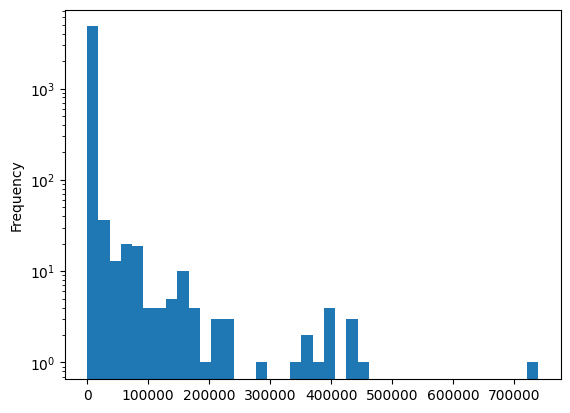

In [193]:
from analytics.metrics.time import TimeMetrics


diffs = TimeMetrics.get_all_diffs(mt_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [194]:
TimeMetrics.get_positive_diff_quantiles(data_subset, timestamp_col, grouping_cols) / 60

# Seems like 5 minutes (90th+ percentile) is a good cutoff for time spent on a problem between submissions
# 30m does seem to suggest that the student is not working on the problem

0.00        0.000017
0.25        0.002933
0.50        0.006483
0.75        0.022183
0.80        0.029333
0.85        0.040711
0.90        0.062883
0.95        0.143483
0.96        0.190124
0.97        0.271856
0.98        0.442505
0.99        0.962250
1.00    20253.148250
Name: DeltaSeconds, dtype: float64

In [195]:
time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
result

C:\Users\twprice\AppData\Local\Temp\ipykernel_2992\3690036271.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  TotalTime  \
SubjectID  ProblemID                                          
13108823   1.076448e+09     279.926      161.617    441.543   
28270295   4.868418e+07     180.852        0.000    180.852   
           1.463363e+08       0.000        0.000      0.000   
           2.546841e+08     437.571      181.200    618.771   
           3.597615e+08     133.654        0.000    133.654   
...                             ...          ...        ...   
4275215466 3.900747e+09     154.119        0.000    154.119   
           3.921830e+09     339.008       83.248    422.256   
           3.940198e+09       0.000        0.000      0.000   
           4.190502e+09       0.000        0.000      0.000   
           4.233866e+09     432.052      267.101    699.153   

                         ActiveTimeAfterCorrect  #Breaks  \
SubjectID  ProblemID                                       
13108823   1.076448e+09                   0.000        0   
28270295   4.868418e+07                   0.000        1   
           1.463363e+08                   0.000        0   
           2.546841e+08                   0.000        1   
           3.597615e+08                   0.000        0   
...                                         ...      ...   
4275215466 3.900747e+09                   0.000        0   
           3.921830e+09                   0.000        0   
           3.940198e+09                   0.000        0   
           4.190502e+09                   6.598        0   
           4.233866e+09                  87.070        1   

                                      StartTime        FirstCorrectTime  \
SubjectID  ProblemID                                                      
13108823   1.076448e+09 2024-09-14 00:57:47.067                     NaT   
28270295   4.868418e+07 2024-09-11 00:29:34.482 2024-09-11 00:36:04.850   
           1.463363e+08 2024-09-04 18:06:51.290 2024-09-04 18:06:51.290   
           2.546841e+08 2024-09-16 18:26:55.020 2024-09-16 18:47:22.580   
           3.597615e+08 2024-09-18 19:14:49.436 2024-09-18 19:17:03.090   
...                                         ...                     ...   
4275215466 3.900747e+09 2024-09-17 12:32:52.741 2024-09-17 12:35:26.860   
           3.921830e+09 2024-09-17 02:40:23.644 2024-09-17 02:47:25.900   
           3.940198e+09 2024-09-03 13:12:09.560 2024-09-03 13:12:09.560   
           4.190502e+09 2024-09-03 12:35:52.210 2024-09-03 12:35:52.210   
           4.233866e+09 2024-09-10 12:46:43.786 2024-09-10 13:01:54.480   

                                        EndTime  
SubjectID  ProblemID                             
13108823   1.076448e+09 2024-09-14 01:05:08.610  
28270295   4.868418e+07 2024-09-11 00:36:04.850  
           1.463363e+08 2024-09-04 18:06:51.290  
           2.546841e+08 2024-09-16 18:47:22.580  
           3.597615e+08 2024-09-18 19:17:03.090  
...                                         ...  
4275215466 3.900747e+09 2024-09-17 12:35:26.860  
           3.921830e+09 2024-09-17 02:47:25.900  
           3.940198e+09 2024-09-03 13:12:09.560  
           4.190502e+09 2024-09-13 18:22:04.873  
           4.233866e+09 2024-09-11 04:06:52.169  

[6782 rows x 8 columns]

In [196]:
result.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,6.782000e+03,6782.000000,6782.000000,6782.000000,6782.000000,6782,6029,6782
mean,2.541741e+02,157.162695,411.336820,8.862507,0.601592,2024-09-11 01:40:12.067022080,2024-09-10 20:25:57.514917888,2024-09-11 15:18:32.746126592
min,-5.684342e-14,0.000000,0.000000,0.000000,0.000000,2024-09-01 01:35:32.500000,2024-09-01 03:52:26.560000,2024-09-01 03:52:26.560000
25%,0.000000e+00,0.000000,4.341750,0.000000,0.000000,2024-09-04 19:01:16.670000128,2024-09-04 18:49:30.089999872,2024-09-05 02:27:25.664999936
50%,1.260645e+02,47.012000,196.971000,0.000000,0.000000,2024-09-11 01:42:35.595500032,2024-09-10 23:26:51.729999872,2024-09-11 15:07:36.607000064
75%,3.626400e+02,199.197000,549.481750,0.000000,1.000000,2024-09-17 00:05:27.448000,2024-09-16 19:07:49.910000128,2024-09-17 13:37:32.372499968
max,6.947802e+03,6630.387000,13578.189000,1452.270000,51.000000,2024-09-22 02:03:08.169000,2024-09-22 02:20:03.840000,2024-09-22 02:23:47.927000
std,3.892666e+02,294.175889,642.057226,48.188750,1.493213,NaN,NaN,NaN


In [200]:
from analytics.metrics.score import SubmissionScoreMetrics
from spec.enums import EventType

score_metrics = SubmissionScoreMetrics(submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_2992\1178317524.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [201]:
subject_problem_score.head()

Attempts  FirstCorrect  EverCorrect  Attempted  \
SubjectID ProblemID                                                      
13108823  1.076448e+09         3         False        False       True   
28270295  4.868418e+07         1          True         True       True   
          1.463363e+08         1          True         True       True   
          2.546841e+08         1          True         True       True   
          3.597615e+08         1          True         True       True   

                        MaxScore  MinScore  MeanScore  TotalAttempts  
SubjectID ProblemID                                                   
13108823  1.076448e+09       0.0       0.0        0.0              3  
28270295  4.868418e+07       1.0       1.0        1.0              1  
          1.463363e+08       1.0       1.0        1.0              1  
          2.546841e+08       1.0       1.0        1.0              1  
          3.597615e+08       1.0       1.0        1.0              1

In [202]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,6782.000000,6782.000000,6782.000000,6782.000000,6782.000000
mean,3.363904,0.891772,0.534503,0.644828,3.695665
std,7.186334,0.308733,0.491332,0.399683,7.515975
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.250000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000
75%,3.000000,1.000000,1.000000,1.000000,3.000000
max,212.000000,1.000000,1.000000,1.000000,212.000000


In [203]:
all_features = pd.merge(
    result.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features.head()

,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
0,13108823,1.076448e+09,279.926,161.617,441.543,0.0,0,2024-09-14 00:57:47.067,NaT,2024-09-14 01:05:08.610,3,False,False,True,0.0,0.0,0.0,3
1,28270295,4.868418e+07,180.852,0.000,180.852,0.0,1,2024-09-11 00:29:34.482,2024-09-11 00:36:04.850,2024-09-11 00:36:04.850,1,True,True,True,1.0,1.0,1.0,1
2,28270295,1.463363e+08,0.000,0.000,0.000,0.0,0,2024-09-04 18:06:51.290,2024-09-04 18:06:51.290,2024-09-04 18:06:51.290,1,True,True,True,1.0,1.0,1.0,1
3,28270295,2.546841e+08,437.571,181.200,618.771,0.0,1,2024-09-16 18:26:55.020,2024-09-16 18:47:22.580,2024-09-16 18:47:22.580,1,True,True,True,1.0,1.0,1.0,1
4,28270295,3.597615e+08,133.654,0.000,133.654,0.0,0,2024-09-18 19:14:49.436,2024-09-18 19:17:03.090,2024-09-18 19:17:03.090,1,True,True,True,1.0,1.0,1.0,1


In [204]:
all_features.isna().mean()

SubjectID                 0.000000
ProblemID                 0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.111029
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.000000
MinScore                  0.000000
MeanScore                 0.000000
TotalAttempts             0.000000
dtype: float64

In [205]:
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [206]:
all_features_z.head()

,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
0,13108823,1.076448e+09,0.323858,0.330160,0.351023,-0.181714,-0.471211,0.766622,-2.498671,0.497377,0.179558,False,False,True,-2.498671,-1.028623,-1.553415,0.034356
1,28270295,4.868418e+07,0.219408,-0.557433,-0.177480,-0.290253,0.584288,0.332236,0.182644,0.226530,-0.321963,True,True,True,0.182590,0.734937,0.698859,-0.349915
2,28270295,1.463363e+08,-0.499051,-0.567312,-0.559024,-0.187739,-0.463748,-0.481657,0.329408,-0.596129,-0.585729,True,True,True,0.329469,1.098231,1.039117,-0.580941
3,28270295,2.546841e+08,0.337377,-0.057829,0.182161,-0.374211,0.635622,-0.723596,0.218213,-0.796558,-0.514290,True,True,True,0.209830,1.065009,0.996756,-0.581443
4,28270295,3.597615e+08,-0.182547,-0.604104,-0.399629,-0.282478,-0.435786,0.055016,0.228263,-0.135648,-0.355273,True,True,True,0.228266,0.570626,0.521899,-0.400645


In [207]:
subject_means = all_features_z.drop(problem_id_col, axis=1).groupby(Cols.SubjectID).mean()
subject_means.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
SubjectID,,,,,,,,,,,,,,,,
13108823,0.323858,0.330160,0.351023,-0.181714,-0.471211,0.766622,-2.498671,0.497377,0.179558,0.000000,0.000000,1.000000,-2.498671,-1.028623,-1.553415,0.034356
28270295,-0.126090,-0.176840,-0.156532,-0.265289,-0.342225,-0.553985,0.219979,-0.671003,-0.365694,0.941176,0.970588,1.000000,0.215807,0.820154,0.772825,-0.399257
30783136,-0.620555,-0.640515,-0.667588,-0.296410,-0.467924,0.092724,-0.324750,-0.008083,0.048211,0.454545,0.818182,0.909091,-0.325220,-0.056005,0.079146,-0.035771
105980555,-0.370503,-0.380084,-0.407087,-0.233284,-0.074915,-0.686393,-0.977047,-0.708721,-0.384119,0.421053,0.526316,0.736842,-0.981266,-0.296381,-0.474336,-0.435579
112044560,-0.494177,-0.569686,-0.561906,-0.175849,-0.478578,1.677975,-3.215685,1.274810,-0.691515,0.000000,0.000000,0.000000,-3.215685,-1.028469,-1.602820,-0.730212


In [208]:
subject_totals = all_features_z.drop(problem_id_col, axis=1).groupby(Cols.SubjectID).sum()
subject_totals.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
SubjectID,,,,,,,,,,,,,,,,
13108823,0.323858,0.330160,0.351023,-0.181714,-0.471211,0.766622,-2.498671,0.497377,0.179558,0,0,1,-2.498671,-1.028623,-1.553415,0.034356
28270295,-4.287065,-6.012572,-5.322088,-9.019811,-11.635654,-18.835474,7.479272,-22.814095,-12.433610,32,33,34,7.337439,27.885224,26.276034,-13.574752
30783136,-6.826102,-7.045661,-7.343465,-3.260509,-5.147162,1.019962,-3.572247,-0.088910,0.530319,5,9,10,-3.577425,-0.616056,0.870609,-0.393478
105980555,-7.039550,-7.221604,-7.734645,-4.432396,-1.423377,-13.041466,-18.563886,-13.465699,-7.298252,8,10,14,-18.644047,-5.631244,-9.012386,-8.275999
112044560,-0.494177,-0.569686,-0.561906,-0.175849,-0.478578,1.677975,-3.215685,1.274810,-0.691515,0,0,0,-3.215685,-1.028469,-1.602820,-0.730212


In [225]:
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=Cols.SubjectID,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,FirstCorrectTime_sum,EndTime_sum,Attempts_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum
0,13108823,0.323858,0.330160,0.351023,-0.181714,-0.471211,0.766622,-2.498671,0.497377,0.179558,...,-2.498671,0.497377,0.179558,0,0,1,-2.498671,-1.028623,-1.553415,0.034356
1,28270295,-0.126090,-0.176840,-0.156532,-0.265289,-0.342225,-0.553985,0.219979,-0.671003,-0.365694,...,7.479272,-22.814095,-12.433610,32,33,34,7.337439,27.885224,26.276034,-13.574752
2,30783136,-0.620555,-0.640515,-0.667588,-0.296410,-0.467924,0.092724,-0.324750,-0.008083,0.048211,...,-3.572247,-0.088910,0.530319,5,9,10,-3.577425,-0.616056,0.870609,-0.393478
3,105980555,-0.370503,-0.380084,-0.407087,-0.233284,-0.074915,-0.686393,-0.977047,-0.708721,-0.384119,...,-18.563886,-13.465699,-7.298252,8,10,14,-18.644047,-5.631244,-9.012386,-8.275999
4,112044560,-0.494177,-0.569686,-0.561906,-0.175849,-0.478578,1.677975,-3.215685,1.274810,-0.691515,...,-3.215685,1.274810,-0.691515,0,0,0,-3.215685,-1.028469,-1.602820,-0.730212


In [226]:
assert subject_features.isna().mean().mean() == 0

In [227]:
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference([Cols.SubjectID])
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,FirstCorrectTime_sum,EndTime_sum,Attempts_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum
0,13108823,0.711982,0.768471,0.751733,-0.380999,-1.070665,0.883937,-1.925514,0.605695,0.514989,...,-0.245471,0.023034,0.013982,-1.262916,-1.465143,-1.482257,-0.241442,-0.078465,-0.109823,0.002608
1,28270295,-0.100588,-0.290208,-0.178658,-0.642665,-0.731621,-0.836568,0.596706,-0.969685,-0.665842,...,0.734767,-1.056546,-0.968186,1.422852,0.403406,0.377579,0.709004,2.127136,1.857665,-1.030587
2,30783136,-0.993552,-1.258418,-1.115466,-0.740103,-1.062024,0.005973,0.091336,-0.075839,0.230535,...,-0.350939,-0.004118,0.041295,-0.843265,-0.955538,-0.975029,-0.345680,-0.046994,0.061550,-0.029873
3,105980555,-0.541978,-0.714607,-0.637945,-0.542461,-0.028987,-1.009072,-0.513831,-1.020542,-0.705742,...,-1.823724,-0.623612,-0.568304,-0.591474,-0.898916,-0.749594,-1.801542,-0.429562,-0.637158,-0.628309
4,112044560,-0.765324,-1.110520,-0.921743,-0.362638,-1.090029,2.071261,-2.590722,1.653945,-1.371457,...,-0.315910,0.059038,-0.053847,-1.262916,-1.465143,-1.538616,-0.310726,-0.078454,-0.113316,-0.055437


In [228]:
grades = dataset.get_link_table(grades_link_table)
grades.head()

,CourseID,SubjectID,URL,approved,final-grade
0,919753123,2596793261,Resources/FinalGrade/919753123_2596793261.yaml,False,0.00
1,919753123,3143505766,Resources/FinalGrade/919753123_3143505766.yaml,False,0.00
2,919753123,3624632776,Resources/FinalGrade/919753123_3624632776.yaml,False,0.44
3,919753123,3215542955,Resources/FinalGrade/919753123_3215542955.yaml,False,3.38
4,919753123,904953019,Resources/FinalGrade/919753123_904953019.yaml,False,0.00


In [229]:
grades.rename(columns={grades_col: "Grade"}, inplace=True)

# CWO only: drop 0 grades
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 189 rows with 0 grades


In [ ]:
# TODO: Need to manage multiple courses in CodeBench dataset!
subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[[Cols.SubjectID, "Grade"]],
    on=Cols.SubjectID,
    how="inner",
)

In [233]:
subject_feautres_labeled.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,EndTime_sum,Attempts_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,Grade
0,28270295,-0.100588,-0.290208,-0.178658,-0.642665,-0.731621,-0.836568,0.596706,-0.969685,-0.665842,...,-1.056546,-0.968186,1.422852,0.403406,0.377579,0.709004,2.127136,1.857665,-1.030587,7.49
1,30783136,-0.993552,-1.258418,-1.115466,-0.740103,-1.062024,0.005973,0.091336,-0.075839,0.230535,...,-0.004118,0.041295,-0.843265,-0.955538,-0.975029,-0.345680,-0.046994,0.061550,-0.029873,8.31
2,105980555,-0.541978,-0.714607,-0.637945,-0.542461,-0.028987,-1.009072,-0.513831,-1.020542,-0.705742,...,-0.623612,-0.568304,-0.591474,-0.898916,-0.749594,-1.801542,-0.429562,-0.637158,-0.628309,1.25
3,141341221,-0.730157,-0.634318,-0.709504,-0.414701,-0.129385,-0.950560,0.209107,-0.988809,0.147420,...,-0.951952,0.022969,-0.087893,-0.049575,0.095786,-0.575244,-0.334250,-0.409018,0.114009,5.91
4,153511603,0.097531,0.089083,0.106438,-0.073279,-0.519774,-0.089131,0.583240,-0.153101,0.841654,...,-0.124147,1.054828,-0.423614,0.743143,0.659372,0.766900,-1.809747,-1.510994,0.865963,6.48


In [234]:
print(len(subject_feautres_labeled))
dir = os.path.join(dataset.data_config.root_path, "analysis")
if not os.path.exists(dir):
    os.makedirs(dir)
subject_feautres_labeled.to_csv(os.path.join(dir, "subject_features.csv"), index=False)

212
